## Main changes
- Added evaluation

# Config

In [2]:
from typing import List, Dict, Any, TypedDict, Optional
from langgraph.graph import StateGraph, START, END
import json
import os
import getpass
import re
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
from pprint import pprint
from pydantic import BaseModel, ValidationError

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  

from schemas.query_check_blueprint import QueryCheckBlueprint
from schemas.planner_blueprint import PlannerBlueprint

from langchain_tavily import TavilySearch
from langchain.agents import create_agent

In [ ]:
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OPENAI_API_KEY:\n")
    
llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)

In [ ]:
if not os.environ.get("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = getpass.getpass("Tavily API key:\n")

tavily_search_tool = TavilySearch(
    max_results=5,
    topic="general",
)

search_agent = create_agent(llm,[tavily_search_tool])

Tavily API key:
 ········


# Agents
---
- Query Agent 
- Planner Agent

In [ ]:
class State(TypedDict):
    graph_state: str
    user_input: str
    
    query_check: Optional[QueryCheckBlueprint]
    query_facts: List[Dict[str, Any]]
    query_approved: bool
    query_attempts: int
    query_feedback: str
    
    plan: Optional[PlannerBlueprint]
    

In [ ]:
def Query_Agent(state: State) -> State:
    user_input = state["user_input"]
    attempts = state.get("query_attempts", 0)

    query_check_prompt = f"""
You are an expert fact-checking agent.
Your task is to analyse the details provided and identify factual claims.
Instructions:
1. Extract every fact from the details.
2. Check each fact for accuracy using reliable public sources.
3. Evaluate whether the fact is relevant to the occasion described.
4. If a fact refers to information that is unlikely to be publicly available, do NOT attempt to fact-check it. Mark it as supported = null.
5. Return ONLY valid JSON. Following the output format strictly.

Details:
{user_input}

Output format:
{{
  "checks_results": [
    {{
      "serial_number": 1,
      "fact_identified": "<extracted factual claim>",
      "supported": <true | false | null>,
      "relevant": <true | false | null>,
      "source_url": "<URL used to verify the claim, or null if not checked>",
      "feedback": "<optional feedback>"
    }}
  ]
}}
"""

    # Step 1: Run search agent to gather facts with web access
    search_result = search_agent.invoke({
        "messages": [
            {"role": "user", "content": query_check_prompt}
        ]
    })

    # Step 2: Extract last assistant message and parse into structured output
    last_message = search_result["messages"][-1].content
    print("FACT CHECK RESULTS")
    print(last_message)
    last_message = search_result["messages"][-1].content
    parsed_json = json.loads(last_message)
    facts = QueryCheckBlueprint.model_validate(parsed_json)

    # Step 3: Evaluate results
    query_approved = True
    feedback_list = []
    for item in facts.checks_results:
        if item.supported is False or item.relevant is False:
            query_approved = False
            feedback_list.append(
                f"Fact: {item.fact_identified}\n"
                f"Supported: {item.supported}\n"
                f"Relevance: {item.relevant}\n"
                f"Feedback: {item.feedback}"
            )

    query_feedback = "\n\n".join(feedback_list)  # cleaner separator

    return {
        "query_check": facts,
        "query_facts": [f.model_dump() for f in facts.checks_results],
        "query_approved": query_approved,
        "query_attempts": attempts + 1,
        "query_feedback": query_feedback,
        "user_input": user_input,
        "graph_state": state["graph_state"],
    }

In [ ]:
def Planner_Agent(state: State) -> dict:
    user_input = state.get("user_input")
    query_facts = state.get("query_facts")

    planner_prompt = f"""
You are an expert speech coach.
Your task:
1. Given verified speech details, produce a structured speech plan.
2. Facts that have undergone fact-checking should be placed under "must_include_facts". All other content should be placed under "must_include_points".
3. estimated_wpm must be an integer between 120 and 150.
4. target_word_count must be calculated using: time_limit_minutes * estimated_wpm.
5. Return ONLY valid JSON. Follow the JSON structure strictly. Do not include explanations or text outside the JSON.

Speech Details: {user_input}
Checked facts: {query_facts}

JSON structure:
{{
  "request": {{
    "topic": "",
    "audience": "",
    "occasion": "",
    "time_limit_minutes": 5
  }},
  "targets": {{
    "estimated_wpm": 130,
    "target_word_count": 650
  }},
  "sections": [
    {{
      "section_id": "S1",
      "name": "",
      "purpose": "",
      "must_include_points": [],
      "must_include_facts": []
    }}
  ]
}}
"""

    response = llm.invoke(planner_prompt)
    print("PLANNER RESPONSE")
    content_str = response.content.strip()
    
    # Robust markdown fence removal
    content_str = re.sub(r"^```(?:json)?\s*\n?", "", content_str)
    content_str = re.sub(r"\n?```$", "", content_str).strip()
    print("CONTENT_STR")
    print(content_str)
    try:
        plan = PlannerBlueprint(**json.loads(content_str))
    except (json.JSONDecodeError, ValidationError) as e:
        raise ValueError(
            f"Planner_Agent failed to parse LLM output: {e}\n"
            f"Raw output:\n{content_str}"
        )

    return {"plan": plan}

In [ ]:
def collect_user_feedback(topic, audience, occasion, time_limit_in_minutes) -> str:
    revised_content = input("Revised Content to be included (i.e. Point, Examples and Facts):").strip()
    return (
        f"Topic: {topic}\n"
        f"Audience: {audience}\n"
        f"Occasion: {occasion}\n"
        f"Time limit (in minutes): {time_limit_in_minutes}\n\n"
        f"Revised Content:\n{revised_content}"
    )

In [ ]:
def Human_Feedback(state: State) -> dict:
    print("\n" + "=" * 50)
    print("FACT-CHECK FAILED — Amendment required")
    print("=" * 50)
    print(f"{state.get('query_feedback', 'No feedback provided.')}")
    print()
    print("Please re-enter your speech content with the issues fixed.")

    # Extract existing values from state
    existing_input = state.get("user_input", "")
    parsed = {}
    for line in existing_input.splitlines():
        for key in ["Topic", "Audience", "Occasion", "Time limit (in minutes)"]:
            if line.startswith(f"{key}:"):
                parsed[key] = line[len(f"{key}:"):].strip()

    updated_input = collect_user_feedback(
        topic=parsed.get("Topic", ""),
        audience=parsed.get("Audience", ""),
        occasion=parsed.get("Occasion", ""),
        time_limit_in_minutes=parsed.get("Time limit (in minutes)", ""),
    )

    return {
        "user_input":     updated_input,
        "graph_state":    updated_input,
        "query_approved": False,
        "query_feedback": "",
    }

# Graph Set up 

In [1]:
def route_user(state):
    approved = state.get("query_approved") or state.get("query_attempts", 0) >= 2
    return "approved" if approved else "rejected"

In [10]:
builder = StateGraph(State)
builder.add_node("Query_Agent", Query_Agent)
builder.add_node("Human_Feedback", Human_Feedback)
builder.add_node("Planner_Agent", Planner_Agent)


In [11]:
builder.add_edge(START, "Query_Agent")
builder.add_edge("Human_Feedback", "Query_Agent") 
builder.add_conditional_edges(
    "Query_Agent",
    route_user,
    {
        "approved": "Planner_Agent",
        "rejected": "Human_Feedback" # HITL - needs to go back to user with feedback
    }
)

In [12]:
builder.add_edge("Planner_Agent", END)

In [13]:
graph = builder.compile()

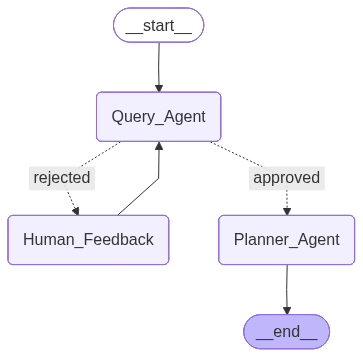

In [14]:
from IPython.display import Image, display
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
def collect_user_input() -> str:
    topic = input("Topic: ").strip()
    audience = input("Audience: ").strip()
    occasion = input("Occasion: ").strip()
    time_limit_in_minutes = input("Time limit (in minutes): ").strip()
    content = input("Content to be included (i.e. Point, Examples and Facts):").strip()

 
    return (
        f"Topic: {topic}\n"
        f"Audience: {audience}\n"
        f"Occasion: {occasion}\n"
        f"Time limit (in minutes): {time_limit_in_minutes}\n\n"
        f"Content:\n{content}"
    )

In [ ]:
def main():
    print("Speech Generator ready. Type 'quit' at any prompt to exit.\n")

    while True:
        try:
            user_input = collect_user_input()
        except (KeyboardInterrupt, EOFError):
            print("\nGoodbye!")
            break

        if user_input.strip().lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        if not user_input.strip():
            continue

        print("\nChecking your content...\n")

        state: State = {
            "graph_state": user_input,
            "user_input": user_input,
            "query_check": None,
            "query_facts": [],
            "query_approved": False,
            "query_attempts": 0,
            "query_feedback": "",
            "plan": None,
        }

        result = graph.invoke(state)

        # Surface feedback if fact-check hit the attempt limit without approving
        if not result.get("query_approved") and result.get("query_feedback"):
            print("Note: Some content could not be verified but the plan was generated anyway.")
            print(f"Feedback: {result['query_feedback']}\n")

        print("\n" + "=" * 50)
        print("YOUR SPEECH PLAN")
        print("=" * 50)

        plan = result.get("plan")

        if isinstance(plan, PlannerBlueprint):
            pprint(plan.model_dump())
        elif isinstance(plan, dict):
            pprint(plan)
        elif isinstance(plan, str):
            try:
                pprint(json.loads(plan))
            except json.JSONDecodeError:
                print(plan)
        else:
            print("No plan generated.")

        again = input("\nGenerate another speech? (y/n): ").strip().lower()
        if again != "y":
            print("Goodbye!")
            break


if __name__ == "__main__":
    main()

Speech Generator ready. Type 'quit' at any prompt to exit.



Topic:  How Singapore can stay competitive by embracing Artificial Intelligence
Audience:  General public of Singaporeans
Occasion:  Singapore National Day Rally
Time limit (in minutes):  8
Content to be included (i.e. Point, Examples and Facts): Theme 1: We are entering a new era with AI Points: None Facts: In 2020, AI struggled to solve basic math problems reliably, but by 2025 it could compete in the International Math Olympiad and achieve a gold medal-level performance. AI is already widely used by Singaporeans, including for travel planning where it can recommend destinations and generate personalised itineraries. In Singapore's civil service, AI is used in agency call centres to transcribe conversations in all four official languages and generate summaries so officers can focus on serving the public. Theme 2: We need to harness the potential of AI to raise productivity and create new value through every part of the economy, keeping our nation competitive Points: Singapore's abili


Checking your content...

FACT CHECK RESULTS
{
  "checks_results": [
    {
      "serial_number": 1,
      "fact_identified": "In 2020, AI struggled to solve basic math problems reliably, but by 2025 it could compete in the International Math Olympiad and achieve a gold medal-level performance.",
      "supported": true,
      "relevant": true,
      "source_url": "https://rits.shanghai.nyu.edu/ai/ai-wins-gold-at-2025-international-mathematical-olympiad/",
      "feedback": "AI achieved gold medal-level performance at the 2025 International Math Olympiad, marking a significant milestone."
    },
    {
      "serial_number": 2,
      "fact_identified": "AI is already widely used by Singaporeans, including for travel planning where it can recommend destinations and generate personalised itineraries.",
      "supported": true,
      "relevant": true,
      "source_url": "https://www.multiable.com/blog/revolutionizing-singapores-travel-and-tourism-industry-through-ai-and-edg-sg",
      "f

# Reference

## Theme 1: We are entering a new era with AI 
### Points: None 
### Facts: In 2020, AI struggled to solve basic math problems reliably, but by 2025 it could compete in the International Math Olympiad and achieve a gold medal-level performance. AI is already widely used by Singaporeans, including for travel planning where it can recommend destinations and generate personalised itineraries. In Singapore's civil service, AI is used in agency call centres to transcribe conversations in all four official languages and generate summaries so officers can focus on serving the public. 
## Theme 2: We need to harness the potential of AI to raise productivity and create new value through every part of the economy, keeping our nation competitive 
### Points: Singapore's ability to combine technology and human expertise attracts high-quality investments and creates good jobs. AI adoption is not limited to large companies, SMEs can also benefit. 
### Facts: AI is being combined with robotics and autonomous machines at Tuas Port and studied for automation at Changi Airport. GE Vernova's turbine repair facility in Singapore uses AI to detect anomalies in turbine components and alert human operators for precise diagnosis. SMEs like Q&M Dental use AI to analyse dental X-rays to help detect fillings, impacted teeth, and tooth decay more accurately. 
## Theme 3: Many people are concerned about job displacement due to AI, but there are opportunities from technological change 
### Points: Technological change in the past created disruption but also enabled workers to move into higher-skilled and better-paying jobs. 
### Facts: In the 1980s, Singapore launched a nationwide computerisation drive that equipped students and workers with computer skills and transformed the economy. When the internet arrived in the 1990s, Singapore successfully adopted it and propelled the nation forward. At PSA, crane operators were retrained to remotely supervise and manage multiple cranes and vehicles, boosting productivity and improving job quality. 
## Theme 4: Even as we embrace AI and technology, Singaporeans will always be our key priority 
### Points: The government will work closely with NTUC and unions to redesign jobs and equip workers with new skills. Efforts to help Singaporeans access jobs include expanded job matching services, more career fairs in tertiary institutions, and a new town-level job matching initiative led by CDCs. The SkillsFuture Level-Up Programme will expand to include more part-time training allowance claims and more courses from industry leaders and private training providers. 
### Facts: The SkillsFuture Level-Up Programme provides Singaporeans aged 40 and above with $4,000 in SkillsFuture credits and training allowances of up to $3,000 per month for up to 24 months for full-time study. Vinoth Nanda Kumaran, aged 41 in 2025, transitioned from private hire driver to Business Intelligence Developer after using SkillsFuture credits to pursue a diploma in data engineering and continuing his studies in Business Analytics at SUSS. 
## Theme 5: Embracing AI is in line with Singapore's broader strategy of building a dynamic, innovative economy that creates good jobs 
### Points: A dynamic economy is one that creates good jobs and better lives for all Singaporeans. Embracing AI supports Singapore's goal of staying globally competitive. Singapore aims to remain ahead through ideas, innovation, and unity. 
### Facts: None

# Evaluation

In [13]:
def evaluate_query(llm, user_input, query_facts):
    prompt = f"""
You are an expert evaluator for a fact-checking agent.
You will be given the user input and agent's output. Your task is to evaluate the following based on the following criteria:
1. extraction_completeness
   - Did the agent find ALL materially verifiable facts in the user input?
   - Penalise omissions of obvious verifiable claims such as statistics, dates, names, achievements.

2. extraction_relevance
   - Are the extracted facts actually relevant to the occasion and speech topic?
   - Penalise misclassification of facts.

3. fact_accuracy_score
   - For facts marked supported=true or supported=false, are the verdicts correct?
   - Penalise wrong verdicts.

4. null_handling_appropriateness
   - Are supported=null used ONLY for genuinely private or unverifiable information?
   - Penalise lazy use of null on facts that ARE publicly verifiable.

5. feedback_usefulness
   - Is the feedback field for false/irrelevant facts actionable and specific?
   - Penalise vague feedback like "this is incorrect".


Score each from 1 (poor) to 5 (excellent).

User Input:
{user_input}

Agent output:
{query_facts}

Respond ONLY in this JSON format:
{{
  "extraction_completeness": <int>,
  "extraction_relevance": <int>,
  "fact_accuracy_score": <int>,
  "null_handling_appropriateness": <int>,
  "feedback_usefulness": <int>
}}
"""

    response = llm.invoke(prompt)
    content = response.content.strip()

    # Clean markdown fences
    content = re.sub(r"^```(?:json)?\s*\n?", "", content)
    content = re.sub(r"\n?```$", "", content).strip()

    try:
        return json.loads(content)
    except json.JSONDecodeError:
        return {
            "error": "Invalid JSON",
            "raw_output": content
        }

In [14]:
def evaluate_planner(llm, user_input, plan, query_facts):
    prompt = f"""
You are an expert evaluator for a speech planning agent. 

You will receive:
- user_input: the original speech request
- query_facts: the list of verified facts from the fact-checking step
- plan_output: the structured JSON plan the planner produced

Your task is to evaluate the user_input based on on these dimensions:

1. fact_placement_accuracy
   - Facts from query_facts that were verified (supported=true) should appear in must_include_facts, NOT in must_include_points.
   - General talking points not from fact-checking go in must_include_points.
   - Score = proportion of facts correctly placed.

2. section_coverage 
   - Does the plan cover a coherent speech structure? (e.g. opening/hook, body/main points, closing/call-to-action)
   - Penalise plans that are just one big section or lack coherence.

3. section_purpose_clarity 
   - Each section's "purpose" field should clearly state WHY that section exists, not just restate its name.
   - Penalise vague purposes like "introduction" with no elaboration.

4. audience_occasion_alignment 
   - Does the plan feel appropriate for the stated audience and occasion?
   - E.g. a wedding toast plan should NOT read like a corporate pitch.

Score each from 1 (poor) to 5 (excellent).

User Input:
{user_input}

Plan:
{plan}

Verified Facts:
{query_facts}

Respond ONLY in this JSON format:
{{
  "fact_placement_accuracy": <int>,
  "section_coverage": <int>,
  "section_purpose_clarity": <int>,
  "audience_occasion_alignment": <int>
}}
"""

    response = llm.invoke(prompt)
    content = response.content.strip()

    content = re.sub(r"^```(?:json)?\s*\n?", "", content)
    content = re.sub(r"\n?```$", "", content).strip()

    try:
        return json.loads(content)
    except json.JSONDecodeError:
        return {
            "error": "Invalid JSON",
            "raw_output": content
        }

In [15]:
user_input = "Theme 1: We are entering a new era with AI Points: None Facts: In 2020, AI struggled to solve basic math problems reliably, but by 2025 it could compete in the International Math Olympiad and achieve a gold medal-level performance. AI is already widely used by Singaporeans, including for travel planning where it can recommend destinations and generate personalised itineraries. In Singapore's civil service, AI is used in agency call centres to transcribe conversations in all four official languages and generate summaries so officers can focus on serving the public. Theme 2: We need to harness the potential of AI to raise productivity and create new value through every part of the economy, keeping our nation competitive Points: Singapore's ability to combine technology and human expertise attracts high-quality investments and creates good jobs. AI adoption is not limited to large companies, SMEs can also benefit. Facts: AI is being combined with robotics and autonomous machines at Tuas Port and studied for automation at Changi Airport. GE Vernova's turbine repair facility in Singapore uses AI to detect anomalies in turbine components and alert human operators for precise diagnosis. SMEs like Q&M Dental use AI to analyse dental X-rays to help detect fillings, impacted teeth, and tooth decay more accurately. Theme 3: Many people are concerned about job displacement due to AI, but there are opportunities from technological change Points: Technological change in the past created disruption but also enabled workers to move into higher-skilled and better-paying jobs. Facts: In the 1980s, Singapore launched a nationwide computerisation drive that equipped students and workers with computer skills and transformed the economy. When the internet arrived in the 1990s, Singapore successfully adopted it and propelled the nation forward. At PSA, crane operators were retrained to remotely supervise and manage multiple cranes and vehicles, boosting productivity and improving job quality. Theme 4: Even as we embrace AI and technology, Singaporeans will always be our key priority Points: The government will work closely with NTUC and unions to redesign jobs and equip workers with new skills. Efforts to help Singaporeans access jobs include expanded job matching services, more career fairs in tertiary institutions, and a new town-level job matching initiative led by CDCs. The SkillsFuture Level-Up Programme will expand to include more part-time training allowance claims and more courses from industry leaders and private training providers. Facts: The SkillsFuture Level-Up Programme provides Singaporeans aged 40 and above with $4,000 in SkillsFuture credits and training allowances of up to $3,000 per month for up to 24 months for full-time study. Vinoth Nanda Kumaran, aged 41 in 2025, transitioned from private hire driver to Business Intelligence Developer after using SkillsFuture credits to pursue a diploma in data engineering and continuing his studies in Business Analytics at SUSS. Theme 5: Embracing AI is in line with Singapore's broader strategy of building a dynamic, innovative economy that creates good jobs Points: A dynamic economy is one that creates good jobs and better lives for all Singaporeans. Embracing AI supports Singapore's goal of staying globally competitive. Singapore aims to remain ahead through ideas, innovation, and unity. Facts: None"

In [16]:
with open("../mocks/mock_planner_blueprint.json", "r") as f:
    plan = json.load(f)

pprint(plan)

{'request': {'audience': 'General public of Singaporeans',
             'occasion': 'Singapore National Day Rally',
             'time_limit_minutes': 8,
             'topic': 'How Singapore can stay competitive by embracing '
                      'Artificial Intelligence'},
 'sections': [{'must_include_facts': ['In 2020, AI struggled to solve basic '
                                      'math problems reliably, but by 2025 it '
                                      'could compete in the International Math '
                                      'Olympiad and achieve a gold medal-level '
                                      'performance',
                                      'AI is already widely used by '
                                      'Singaporeans, including for travel '
                                      'planning where it can recommend '
                                      'destinations and generate personalised '
                                      'itineraries'

In [17]:
with open("../mocks/mock_query_facts.json", "r") as f:
    query_facts = json.load(f)

pprint(query_facts)

{'checks_results': [{'fact_identified': 'In 2020, AI struggled to solve basic '
                                        'math problems reliably, but by 2025 '
                                        'it could compete in the International '
                                        'Math Olympiad and achieve a gold '
                                        'medal-level performance.',
                     'feedback': 'AI achieved gold medal-level performance at '
                                 'the 2025 International Math Olympiad, '
                                 'marking a significant milestone.',
                     'relevant': True,
                     'serial_number': 1,
                     'source_url': 'https://rits.shanghai.nyu.edu/ai/ai-wins-gold-at-2025-international-mathematical-olympiad/',
                     'supported': True},
                    {'fact_identified': 'AI is already widely used by '
                                        'Singaporeans, including for tr

In [18]:
query_eval = evaluate_query(llm, user_input, query_facts)

planner_eval = evaluate_planner(llm, user_input, plan, query_facts)

In [19]:
query_eval

{'extraction_completeness': 5,
 'extraction_relevance': 5,
 'fact_accuracy_score': 5,
 'null_handling_appropriateness': 5,
 'feedback_usefulness': 5}

In [20]:
planner_eval

{'fact_placement_accuracy': 5,
 'section_coverage': 5,
 'section_purpose_clarity': 5,
 'audience_occasion_alignment': 5}